In [1]:
base_url = "https://cdn.jsdelivr.net/gh/bbadzioch/mth337_site@main/projects/text_attribution/books/"

training_urls = {
    "addams_democracy": base_url + "addams_democracy.txt",
    "emerson_conduct": base_url + "emerson_conduct.txt",
    "fuller_life": base_url + "fuller_life.txt",
    "muir_boyhood": base_url + "muir_boyhood.txt",
    "thoreau_journal": base_url + "thoreau_journal.txt"
}

test_urls = {
    "addams_conscience": base_url + "addams_conscience.txt",
    "addams_hull_house": base_url + "addams_hull_house.txt",
    "addams_youth": base_url + "addams_youth.txt",
    "emerson_english": base_url + "emerson_english.txt",
    "emerson_nature": base_url + "emerson_nature.txt",
    "emerson_representative_men": base_url + "emerson_representative_men.txt",
    "fuller_europe": base_url + "fuller_europe.txt",
    "fuller_summer": base_url + "fuller_summer.txt",
    "fuller_woman": base_url + "fuller_woman.txt",
    "muir_sierra": base_url + "muir_sierra.txt",
    "muir_walk": base_url + "muir_walk.txt",
    "muir_yosemite": base_url + "muir_yosemite.txt",
    "thoreau_walden": base_url + "thoreau_walden.txt",
    "thoreau_yankee": base_url + "thoreau_yankee.txt",
    "thoreau_rivers": base_url + "thoreau_rivers.txt"
}

In [2]:
import requests

In [4]:
training_texts = {}
for t in training_urls:
    print(t)
    text = requests.get(training_urls[t]).text
    training_texts[t] = text

addams_democracy
emerson_conduct
fuller_life
muir_boyhood
thoreau_journal


In [5]:
print(training_texts["addams_democracy"][:1000])


DEMOCRACY AND SOCIAL ETHICS




CHAPTER I

INTRODUCTION


It is well to remind ourselves, from time to time, that "Ethics" is but
another word for "righteousness," that for which many men and women of
every generation have hungered and thirsted, and without which life
becomes meaningless.

Certain forms of personal righteousness have become to a majority of the
community almost automatic. It is as easy for most of us to keep from
stealing our dinners as it is to digest them, and there is quite as much
voluntary morality involved in one process as in the other. To steal
would be for us to fall sadly below the standard of habit and
expectation which makes virtue easy. In the same way we have been
carefully reared to a sense of family obligation, to be kindly and
considerate to the members of our own households, and to feel
responsible for their well-being. As the rules of conduct have become
established in regard to our self-development and our families, so they
have been in regard to l

In [9]:
test_texts = {}
for t in test_urls:
    print(t)
    text = requests.get(test_urls[t]).text
    test_texts[t] = text

addams_conscience
addams_hull_house
addams_youth
emerson_english
emerson_nature
emerson_representative_men
fuller_europe
fuller_summer
fuller_woman
muir_sierra
muir_walk
muir_yosemite
thoreau_walden
thoreau_yankee
thoreau_rivers


In [10]:
print(test_texts["fuller_europe"][:1000])

THINGS AND THOUGHTS IN EUROPE.




LETTER I.

PASSAGE IN THE CAMBRIA.--LORD AND LADY FALKLAND.--CAPTAIN
JUDKINS.--LIVERPOOL.--MANCHESTER.--MECHANICS' INSTITUTE.--"THE
DIAL."--PEACE AND WAR.--THE WORKING-MEN OF ENGLAND.--THEIR TRIBUTE TO
SIR ROBERT PEEL.--THE ROYAL INSTITUTE.--STATUES.--CHESTER.--BATHING.


Ambleside, Westmoreland, 23d August, 1846.

I take the first interval of rest and stillness to be filled up by
some lines for the Tribune. Only three weeks have passed since leaving
New York, but I have already had nine days of wonder in England, and,
having learned a good deal, suppose I may have something to tell.

Long before receiving this, you know that we were fortunate in the
shortest voyage ever made across the Atlantic,[A]--only ten days
and sixteen hours from Boston to Liverpool. The weather and all
circumstances were propitious; and, if some of us were weak of head
enough to suffer from the smell and jar of the machinery, or other
ills by which the sea is wont to avenge it

In [11]:
import string

def clean_text(txt):
    
    letters = []
    for c in txt.lower():
        if c in string.ascii_lowercase:
            letters.append(c)
        else:
            letters.append(" ")

    ctxt = "".join(letters)
    return ctxt

In [13]:
ctxt = clean_text(training_texts["addams_democracy"])
print(ctxt[:1000])

 democracy and social ethics     chapter i  introduction   it is well to remind ourselves  from time to time  that  ethics  is but another word for  righteousness   that for which many men and women of every generation have hungered and thirsted  and without which life becomes meaningless   certain forms of personal righteousness have become to a majority of the community almost automatic  it is as easy for most of us to keep from stealing our dinners as it is to digest them  and there is quite as much voluntary morality involved in one process as in the other  to steal would be for us to fall sadly below the standard of habit and expectation which makes virtue easy  in the same way we have been carefully reared to a sense of family obligation  to be kindly and considerate to the members of our own households  and to feel responsible for their well being  as the rules of conduct have become established in regard to our self development and our families  so they have been in regard to l

In [14]:
words = ctxt.split()
words[:20]

['democracy',
 'and',
 'social',
 'ethics',
 'chapter',
 'i',
 'introduction',
 'it',
 'is',
 'well',
 'to',
 'remind',
 'ourselves',
 'from',
 'time',
 'to',
 'time',
 'that',
 'ethics',
 'is']

In [26]:
import numpy as np

def get_word_lengths(txt, max_length):
    ctxt = clean_text(txt)
    words = ctxt.split()
    word_lengths = np.zeros(max_length)
    for w in words:
        if len(w) < max_length:
            word_lengths[len(w)] += 1
    return word_lengths/len(words)
    

In [29]:
txt = training_texts["addams_democracy"]
wl = get_word_lengths(txt, 18)
wl

array([0.00000000e+00, 2.52580294e-02, 1.82917708e-01, 2.23304913e-01,
       1.56313439e-01, 9.91302861e-02, 7.98341774e-02, 7.41927901e-02,
       5.33367524e-02, 4.00880398e-02, 3.43611770e-02, 1.51291749e-02,
       8.44071201e-03, 5.06442721e-03, 1.53856016e-03, 7.26542300e-04,
       2.56426694e-04, 1.06844456e-04])

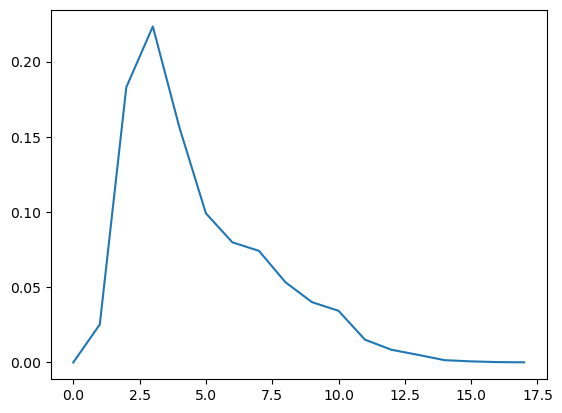

In [31]:
import matplotlib.pyplot as plt

plt.plot(wl)
plt.show()

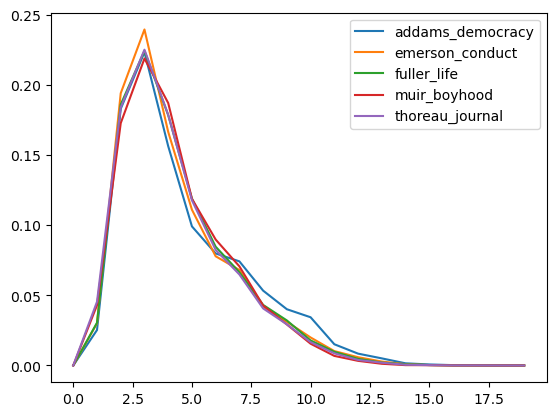

In [33]:
for t in training_texts:
    txt = training_texts[t]
    wl = get_word_lengths(txt, max_length=20)
    plt.plot(wl, label=t)
    plt.legend()
plt.show()

In [36]:
test = test_texts["addams_conscience"]
test_wl = get_word_lengths(test, 20)
test_wl

array([0.00000000e+00, 2.57674488e-02, 1.66423032e-01, 2.08567677e-01,
       1.61120884e-01, 1.13797973e-01, 7.94331161e-02, 7.84916132e-02,
       5.38886549e-02, 4.39037685e-02, 3.28534972e-02, 1.75416863e-02,
       1.02574267e-02, 5.32692451e-03, 2.15554620e-03, 3.71645896e-04,
       7.43291792e-05, 2.47763931e-05, 0.00000000e+00, 0.00000000e+00])

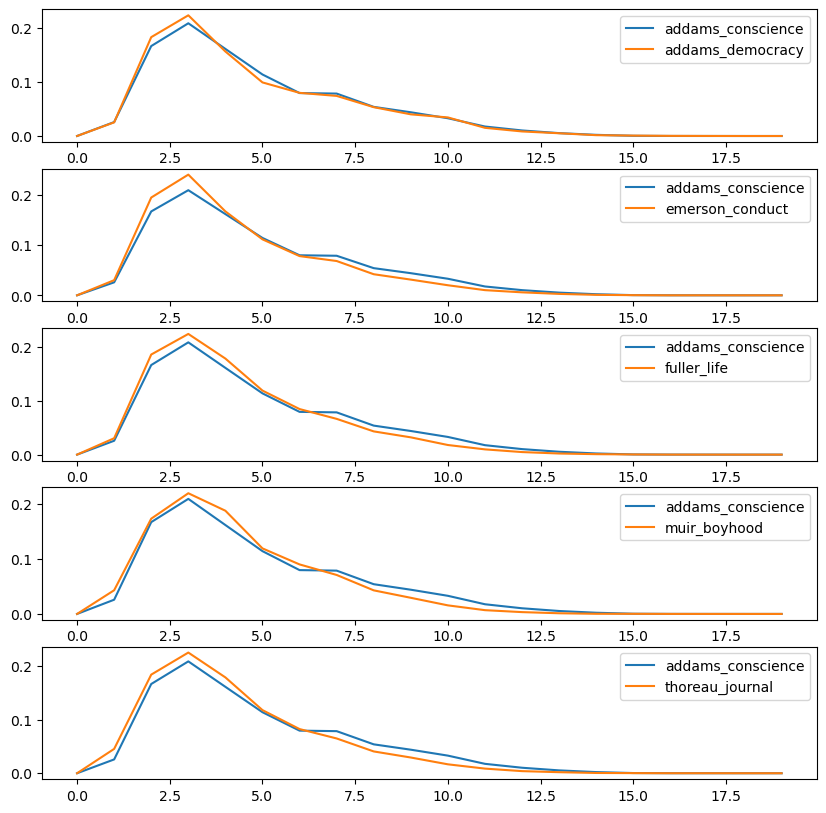

In [38]:
i = 1

plt.figure(figsize=(10, 10))

for t in training_texts:
    plt.subplot(5, 1, i)
    plt.plot(test_wl, label="addams_conscience")
    txt = training_texts[t]
    wl = get_word_lengths(txt, max_length=20)
    plt.plot(wl, label=t)
    plt.legend()
    i += 1
plt.show()
    

In [41]:
def vector_distance(v1, v2):
    dist = np.mean(np.abs(v1 - v2))
    return dist

In [42]:
for t in training_texts:
    txt = training_texts[t]
    wl = get_word_lengths(txt, max_length=20)
    print(t, vector_distance(test_wl, wl))

addams_democracy 0.0033759715325390677
emerson_conduct 0.006810587102679911
fuller_life 0.006755431146618675
muir_boyhood 0.007488759465496398
thoreau_journal 0.007802976270527487


In [44]:
import seaborn as sns

In [45]:
rng = np.random.default_rng()
scores = rng.random((15, 5))
scores

array([[0.92914819, 0.55469725, 0.4980661 , 0.56532267, 0.80477537],
       [0.6480782 , 0.02357734, 0.98389918, 0.55802454, 0.15696583],
       [0.37301398, 0.14804342, 0.32828411, 0.70572288, 0.4598805 ],
       [0.47549277, 0.46117163, 0.99406475, 0.34268391, 0.57807239],
       [0.84659651, 0.64622823, 0.28078614, 0.84115213, 0.07569579],
       [0.71205999, 0.46487119, 0.96510858, 0.5353983 , 0.99346957],
       [0.57229006, 0.97969952, 0.76164066, 0.39693501, 0.63533705],
       [0.31980971, 0.91546283, 0.86469689, 0.48809043, 0.5572613 ],
       [0.72146525, 0.81638429, 0.53827037, 0.31408492, 0.32674438],
       [0.91561472, 0.08219742, 0.12700255, 0.50955931, 0.94510957],
       [0.93983185, 0.88330494, 0.25926469, 0.4293435 , 0.1575877 ],
       [0.77090702, 0.43446423, 0.32579637, 0.73193493, 0.91378802],
       [0.68265983, 0.92564247, 0.44788983, 0.18320634, 0.73741408],
       [0.7735019 , 0.18195773, 0.62888824, 0.27013769, 0.3312581 ],
       [0.38286223, 0.63162017, 0.

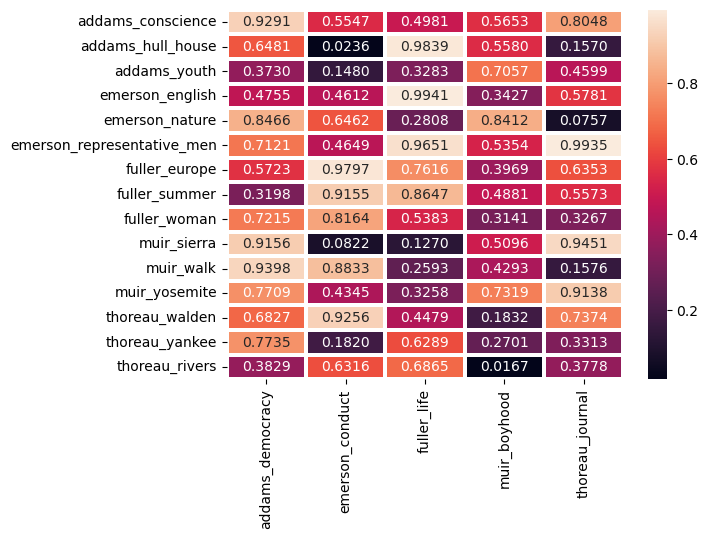

In [59]:
sns.heatmap(scores,
            xticklabels = training_texts.keys(),
            yticklabels = test_texts.keys(),
            annot=True,
            fmt=".4f",
            #cmap="viridis"
            linewidth=1.7,
            #linecolor="green"
    
)
plt.show()

In [60]:
lst = ["a", "b", "c"]

for i, x in enumerate(lst):
    print(i, x)

0 a
1 b
2 c


In [62]:
for i, t in enumerate(training_texts.keys()):
    print(i, t)

0 addams_democracy
1 emerson_conduct
2 fuller_life
3 muir_boyhood
4 thoreau_journal


In [67]:
import urllib.request

In [69]:
r = urllib.request.urlopen("https://mth548.org")

In [71]:
dir(r)

['__abstractmethods__',
 '__class__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__next__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '_abc_impl',
 '_checkClosed',
 '_checkReadable',
 '_checkSeekable',
 '_checkWritable',
 '_check_close',
 '_close_conn',
 '_get_chunk_left',
 '_method',
 '_peek_chunked',
 '_read1_chunked',
 '_read_and_discard_trailer',
 '_read_chunked',
 '_read_next_chunk_size',
 '_read_status',
 '_readinto_chunked',
 '_safe_read',
 '_safe_readinto',
 'begin',
 'chunk_left',
 'chunked',
 'close',
 'closed',
 'code',
 'debuglevel',
 'detach',
 'fileno',
 'flush',
 'fp',
 'getcode',
 'getheader',
 'getheaders',
 'geturl',
 'headers',
 'info',
 'isatty'